In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg

palette = {
    "gamma1": "#E76F51",
    "gamma2": "#EFAE22",
    "gamma3": "#DCCF67",
    "gamma4": "#95BE56",
    "gamma5": "#4FA9D9",
    "betap2": "#A566A8",
}


# Ext Dat Fig 6g

In [2]:
mw_long_ds = pd.read_csv('moonwalker_alldans_ds10Hz_dff0.csv')

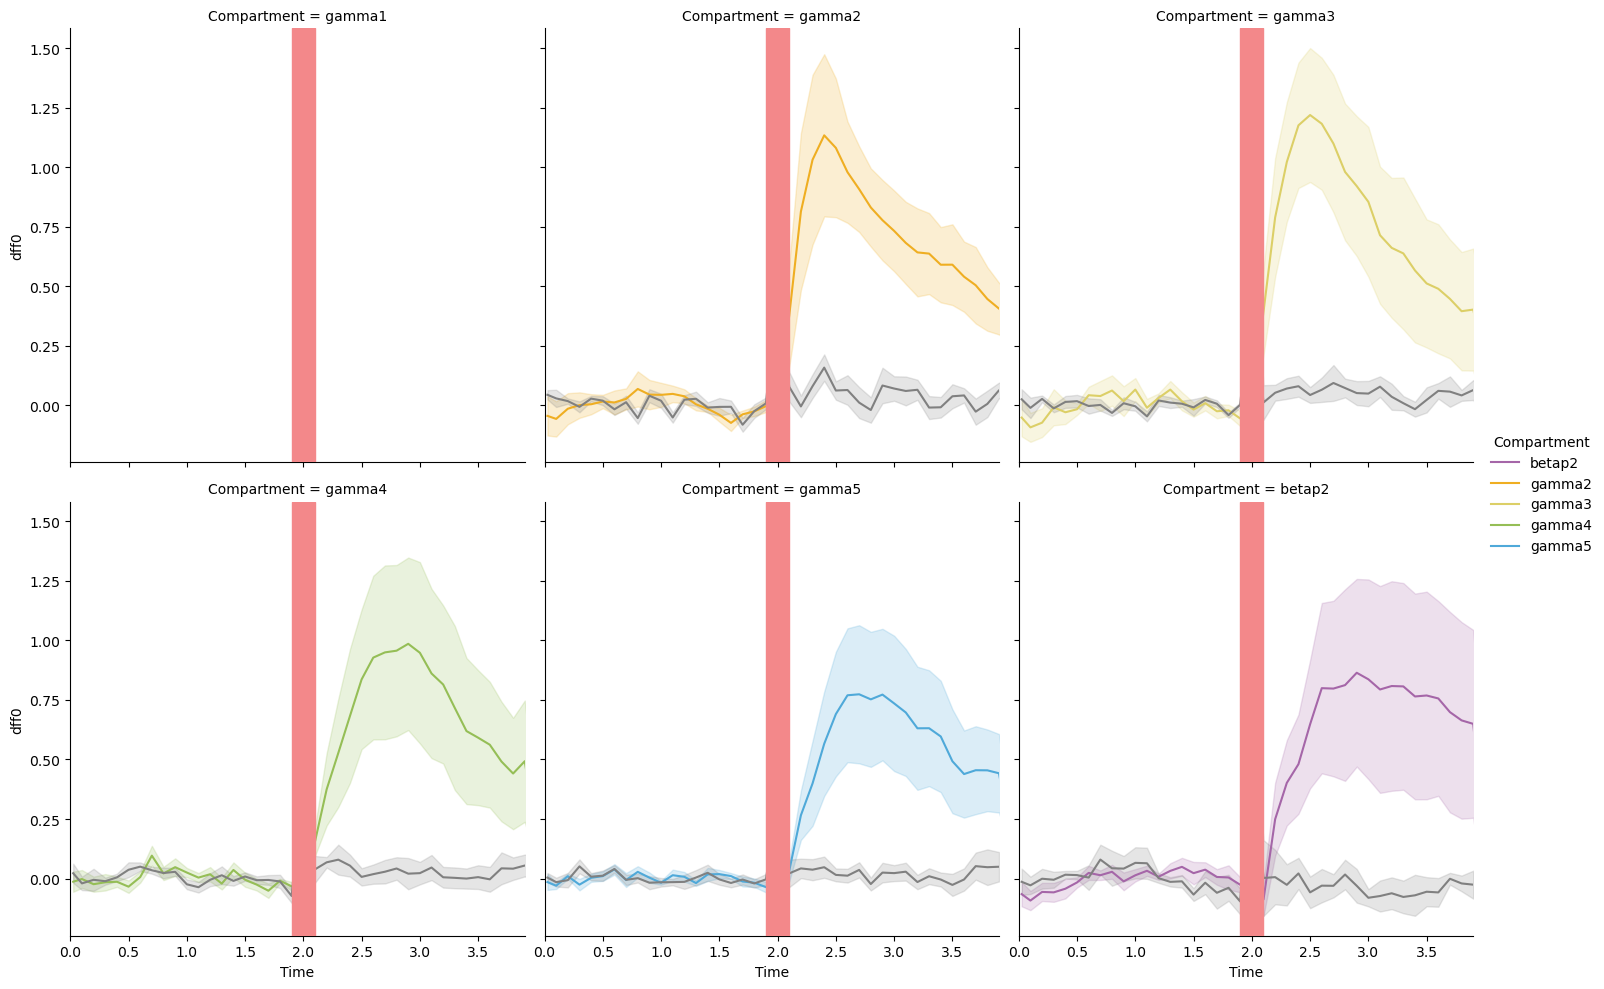

In [3]:
g = sns.relplot(
    data=mw_long_ds.query("Genotype == 'Chrimson'"),
    x='Time', y='dff0',
    hue='Compartment',
    kind='line', errorbar='se',
    col='Compartment', col_wrap=3,
    col_order=list(palette.keys()),
    palette=palette
)

# overlay '+' as grey
for comp, ax in zip(g.col_names, g.axes.flatten()):
    sns.lineplot(
        data=mw_long_ds.query("Genotype == '+' and Compartment == @comp"),
        x='Time', y='dff0',
        color='grey',
        errorbar='se',
        ax=ax,
        legend=False
    )

g.set(xlim=(0, 3.9))

for ax in g.axes.flatten():
    ax.axvspan(1.9, 2.1, color='#f3888a', alpha=1.0, zorder=10)

In [4]:
mw_long_ds['prepost'] = np.nan
mw_long_ds.loc[mw_long_ds.Time<1.8, 'prepost'] = 'pre'
mw_long_ds.loc[mw_long_ds.Time>2.2, 'prepost'] = 'post'
mw_stats = mw_long_ds.groupby(['Genotype', 'Compartment', 'Trial', 'prepost']).mean()['dff0'].reset_index()
mw_stats['prepost'] = pd.Categorical(mw_stats['prepost'],
                                   categories=['pre', 'post'],
                                   ordered=True)
mw_stats


/var/folders/lr/x3_df06s0z7167lnqf_6s2xh0000gn/T/ipykernel_78698/2653317512.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'pre' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  mw_long_ds.loc[mw_long_ds.Time<1.8, 'prepost'] = 'pre'


,Genotype,Compartment,Trial,prepost,dff0
0,+,betap2,0,post,0.051747
1,+,betap2,0,pre,-0.000831
2,+,betap2,1,post,-0.049166
3,+,betap2,1,pre,0.003678
4,+,betap2,2,post,-0.119241
...,...,...,...,...,...
113,Chrimson,gamma5,4,pre,0.000589
114,Chrimson,gamma5,5,post,1.750763
115,Chrimson,gamma5,5,pre,0.010973
116,Chrimson,gamma5,6,post,0.201800


In [5]:
mw_stats_delta = mw_stats.loc[mw_stats.prepost=='post'].reset_index(drop=True)
mw_stats_delta['dff0'] -= mw_stats.loc[mw_stats.prepost=='pre', 'dff0'].values
mw_stats_delta

,Genotype,Compartment,Trial,prepost,dff0
0,+,betap2,0,post,0.052577
1,+,betap2,1,post,-0.052844
2,+,betap2,2,post,-0.135197
3,+,gamma2,0,post,0.039854
4,+,gamma2,1,post,-0.009987
5,+,gamma2,2,post,0.003645
6,+,gamma2,3,post,-0.007755
7,+,gamma2,4,post,0.238055
8,+,gamma2,5,post,-0.019052
9,+,gamma3,0,post,0.121248


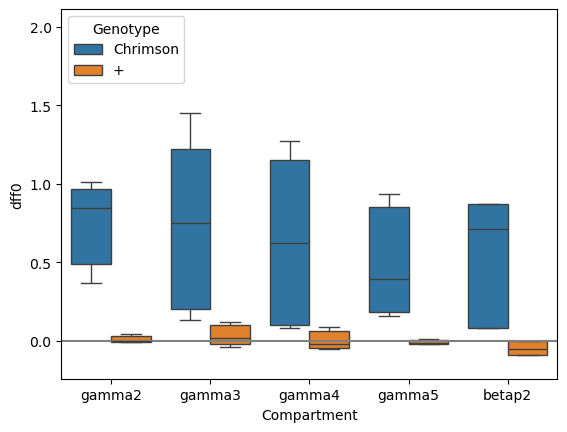

In [6]:
sns.boxplot(data=mw_stats_delta, x='Compartment', y='dff0', hue='Genotype', fliersize=0, order=list(palette.keys())[1:],
            hue_order=['Chrimson', '+'], whis=(10, 90))
plt.axhline(0, color='grey')

In [7]:
pvals_unspec = []
for comp in mw_stats_delta.Compartment.unique():
    pvals_unspec.append(pg.pairwise_tests(mw_stats_delta.loc[mw_stats_delta.Compartment==comp], dv='dff0', between='Genotype',
                               subject='Trial', parametric=False)['p-unc'].values[0])
pd.DataFrame(pg.multicomp(pvals_unspec, method='holm'), columns=mw_stats_delta.Compartment.unique())

,betap2,gamma2,gamma3,gamma4,gamma5
0,False,True,False,False,False
1,0.142857,0.021645,0.055944,0.142857,0.104895
